# Sesión 01: EDA, calidad de datos, preprocesamiento y pipelines


**Aprendizaje de Máquina Aplicado**

**Profesor:** Marco Teran <br>
**Estudiantes:** Isis Catitza Amaya Arbelaez <br>
Santiago Alberto Rozo Silva <br>
Samuel Oviedo Paz <br>
**Fecha:** 2026


[Github](https://github.com/SamuelOviedo2003/ml-embalses-colombia.git)

In [1]:
# Configuración inicial del entorno
import sys
import warnings

warnings.filterwarnings('ignore')

# Verificar versión de Python
assert sys.version_info >= (3, 7), "Este notebook requiere Python 3.7 o superior"

print(f"Python {sys.version_info.major}.{sys.version_info.minor}.{sys.version_info.micro} instalado correctamente")

Python 3.13.13 instalado correctamente


In [6]:
import sys
!{sys.executable} -m pip install numpy pandas matplotlib seaborn scipy scikit-learn

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/8.0 MB ? eta -:--:--
   ----------------- ---------------------- 3.4/8.0 MB 25.8 MB/s eta 0:00:01
   ---------------------------------------- 8.0/8.0 MB 25.0 MB/s  0:00:00

   ------------- -------------------------- 1/3 [joblib]
   ------------- -------------------------- 1/3 [joblib]
   ------------- -------------------------- 1/3 [joblib]
   ------------- -------------------------- 1/3 [joblib]
   ------------- -------------------------- 1/3 [joblib]
   ------------- -------------------------- 1/3 [joblib]
   -------------------------- ------------- 2/3 [scikit-learn]
   -------------------------- ------------- 2/3 [scikit-learn]
   -------------------------- ------------- 2/3 [scikit-learn]
   -------------------------- ------------- 2/3 [scikit-learn]
   -------------------------- ------------- 2/3 [scikit-learn]
   -------------------------- ------------- 

In [7]:
# Importar librerías necesarias
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from typing import Iterable, Optional
from scipy import stats

print("Librerías importadas correctamente")

Librerías importadas correctamente


In [8]:
# Verificar versiones de librerías críticas
from packaging import version
from sklearn.model_selection import train_test_split
import sklearn

assert version.parse(sklearn.__version__) >= version.parse("1.0.1"), "Requiere scikit-learn >= 1.0.1"
print(f"scikit-learn {sklearn.__version__} instalado")

scikit-learn 1.8.0 instalado


In [31]:
def print_section(title: str, width: int = 88) -> None:
    """Print a visual section delimiter."""
    print("\n" + "=" * width)
    print(title.center(width))
    print("=" * width)


def summarize_schema(df: pd.DataFrame, target: Optional[str] = None) -> pd.DataFrame:
    """Return a compact schema summary."""
    summary = pd.DataFrame({
        "column": df.columns,
        "dtype": df.dtypes.astype(str).values,
        "non_null": df.notna().sum().values,
        "missing": df.isna().sum().values,
        "missing_pct": (df.isna().mean().values * 100).round(2),
        "n_unique": df.nunique(dropna=True).values,
    })
    summary["role"] = "feature"
    if target is not None and target in summary["column"].values:
        summary.loc[summary["column"] == target, "role"] = "target"
    return summary.sort_values(["role", "missing_pct", "column"], ascending=[False, False, True]).reset_index(drop=True)


def missing_summary(df: pd.DataFrame) -> pd.DataFrame:
    """Return a missing-value summary sorted by missingness."""
    out = pd.DataFrame({
        "column": df.columns,
        "missing": df.isna().sum().values,
        "missing_pct": (df.isna().mean().values * 100).round(2),
        "dtype": df.dtypes.astype(str).values,
    })
    out = out.sort_values(["missing", "column"], ascending=[False, True]).reset_index(drop=True)
    return out


def detect_duplicate_rows(df: pd.DataFrame) -> pd.DataFrame:
    """Return duplicated rows."""
    dup_mask = df.duplicated(keep=False)
    return df.loc[dup_mask].copy()


def iqr_outlier_rate(series: pd.Series) -> float:
    """Return the percentage of IQR-rule outliers for a numeric series."""
    s = series.dropna()
    if s.empty:
        return 0.0
    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1
    if iqr == 0:
        return 0.0
    mask = (s < q1 - 1.5 * iqr) | (s > q3 + 1.5 * iqr)
    return round(mask.mean() * 100, 2)


def numeric_profile(df: pd.DataFrame, columns: Iterable[str]) -> pd.DataFrame:
    """Return a robust numeric profile for selected columns."""
    rows = []
    for col in columns:
        s = df[col].dropna()
        rows.append({
            "column": col,
            "mean": s.mean(),
            "median": s.median(),
            "std": s.std(),
            "min": s.min(),
            "q1": s.quantile(0.25),
            "q3": s.quantile(0.75),
            "max": s.max(),
            "skew": s.skew(),
            "outlier_pct_iqr": iqr_outlier_rate(df[col]),
        })
    return pd.DataFrame(rows).round(3)


def plot_missing_matrix(df: pd.DataFrame, max_rows: int = 250) -> None:
    """Visualize missingness as a compact matrix."""
    sample = df.head(max_rows)
    matrix = sample.isna().astype(int).T.values

    fig, ax = plt.subplots(figsize=(12, 4))
    ax.imshow(matrix, aspect="auto", interpolation="nearest")
    ax.set_title("Mapa de missingness (columnas × filas)")
    ax.set_xlabel("Filas (muestra inicial)")
    ax.set_ylabel("Columnas")
    ax.set_yticks(range(len(sample.columns)))
    ax.set_yticklabels(sample.columns)
    ax.set_xticks([])
    plt.tight_layout()
    plt.show()


def plot_missing_bars(df: pd.DataFrame) -> None:
    """Bar plot of missing percentages."""
    miss = missing_summary(df)
    miss = miss[miss["missing"] > 0]
    if miss.empty:
        print("✅ No hay valores faltantes en el dataset de trabajo.")
        return

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.bar(miss["column"], miss["missing_pct"])
    ax.set_title("Porcentaje de valores faltantes por columna")
    ax.set_ylabel("% faltante")
    ax.set_xlabel("Columna")
    ax.axhline(5, linestyle="--", linewidth=1)
    ax.tick_params(axis="x", rotation=45)
    plt.tight_layout()
    plt.show()


def plot_numeric_audit(df: pd.DataFrame, columns: list[str], target: str) -> None:
    """Plot histogram, boxplot, and target scatter for selected numeric columns."""
    for col in columns:
        fig, axes = plt.subplots(1, 3, figsize=(16, 4))

        # Histograma
        axes[0].hist(df[col].dropna(), bins=40, edgecolor="black", alpha=0.8)
        axes[0].axvline(df[col].mean(), linestyle="--", linewidth=1, label=f"Media: {df[col].mean():.2f}")
        axes[0].axvline(df[col].median(), linestyle=":", linewidth=1, label=f"Mediana: {df[col].median():.2f}")
        axes[0].set_title(f"Distribución: {col}")
        axes[0].set_xlabel(col)
        axes[0].set_ylabel("Frecuencia")
        axes[0].legend()

        # Boxplot
        axes[1].boxplot(df[col].dropna(), vert=True, patch_artist=True)
        axes[1].set_title(f"Boxplot: {col}")
        axes[1].set_ylabel(col)

        # Relación con target
        valid = df[[col, target]].dropna()
        axes[2].scatter(valid[col], valid[target], alpha=0.2, s=10)
        axes[2].set_title(f"{col} vs {target}")
        axes[2].set_xlabel(col)
        axes[2].set_ylabel(target)

        plt.tight_layout()
        plt.show()


def plot_categorical_audit(df: pd.DataFrame, cat_col: str, target: str) -> None:
    """Audit a categorical feature."""
    counts = df[cat_col].fillna("MISSING").value_counts(dropna=False)

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    axes[0].bar(counts.index.astype(str), counts.values)
    axes[0].set_title(f"Distribución de categorías: {cat_col}")
    axes[0].set_xlabel(cat_col)
    axes[0].set_ylabel("Frecuencia")
    axes[0].tick_params(axis="x", rotation=45)

    grouped = df[[cat_col, target]].copy()
    grouped[cat_col] = grouped[cat_col].fillna("MISSING")
    category_order = counts.index.astype(str).tolist()

    data_for_box = [
        grouped.loc[grouped[cat_col].astype(str) == level, target].dropna().values
        for level in category_order
    ]
    axes[1].boxplot(data_for_box, labels=category_order, patch_artist=True)
    axes[1].set_title(f"{target} por categoría: {cat_col}")
    axes[1].set_xlabel(cat_col)
    axes[1].set_ylabel(target)
    axes[1].tick_params(axis="x", rotation=45)

    plt.tight_layout()
    plt.show()


def plot_correlation_heatmap(df: pd.DataFrame, columns: list[str]) -> None:
    """Simple correlation heatmap using matplotlib only."""
    corr = df[columns].corr(numeric_only=True)

    fig, ax = plt.subplots(figsize=(8, 6))
    im = ax.imshow(corr.values, aspect="auto", interpolation="nearest", vmin=-1, vmax=1)
    ax.set_xticks(range(len(corr.columns)))
    ax.set_xticklabels(corr.columns, rotation=45, ha="right")
    ax.set_yticks(range(len(corr.index)))
    ax.set_yticklabels(corr.index)
    ax.set_title("Matriz de correlación")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.show()


def quick_interpretation(df: pd.DataFrame, target: str, numeric_cols: list[str]) -> None:
    """Print short interpretation cues after EDA."""
    print_section("LECTURA RÁPIDA DEL EDA")
    print(f"- Filas: {df.shape[0]:,}")
    print(f"- Columnas: {df.shape[1]}")
    print(f"- Target: {target}")
    print(f"- Variables numéricas: {len(numeric_cols)}")
    print(f"- Variables categóricas: {df.select_dtypes(exclude=[np.number]).shape[1]}")
    print(f"- Valores faltantes totales: {int(df.isna().sum().sum())}")
    print(f"- Filas duplicadas exactas: {int(df.duplicated().sum())}")


In [14]:
# Ruta al dataset
data_path = Path("Datasets/dataset_final.csv")

# Cargar dataset
housing = pd.read_csv(data_path)

# Definir target
TARGET = "reserva_pct" 

print(f"✅ Dataset cargado desde: {data_path}")
print(f"✅ Shape: {housing.shape[0]:,} filas × {housing.shape[1]} columnas")

✅ Dataset cargado desde: Datasets\dataset_final.csv
✅ Shape: 115,380 filas × 9 columnas


In [15]:
print_section("PRIMERA INSPECCIÓN")

display(housing.head())

print("\nTipos de datos:")
display(housing.dtypes.to_frame(name="dtype").T)

print("\nDescripción numérica rápida:")
display(housing.describe(include=[np.number]).T)


                                   PRIMERA INSPECCIÓN                                   


,Fecha,CodigoEmbalse,RegionHidrologica,reserva_pct,aportes_masa,media_historica_masa,aportes_vs_media_pct,oni,mei_v2
0,2013-01-01,AGREGADO_BOGOTA,Centro,78.07,230740000.0,337530000.0,68.361331,-0.4,-0.06
1,2013-01-01,AGREGADO_SIN,Colombia,73.21,NaN,NaN,NaN,-0.4,-0.06
2,2013-01-01,ALTOANCH,Valle,42.61,131910000.0,251100000.0,52.532855,-0.4,-0.06
3,2013-01-01,BETANIA,Centro,79.99,230740000.0,337530000.0,68.361331,-0.4,-0.06
4,2013-01-01,CALIMA1,Valle,75.15,131910000.0,251100000.0,52.532855,-0.4,-0.06



Tipos de datos:


,Fecha,CodigoEmbalse,RegionHidrologica,reserva_pct,aportes_masa,media_historica_masa,aportes_vs_media_pct,oni,mei_v2
dtype,str,str,str,float64,float64,float64,float64,float64,float64



Descripción numérica rápida:


,count,mean,std,min,25%,50%,75%,max
reserva_pct,115380.0,6.321155e+01,2.480241e+01,-1.85,4.567000e+01,6.437000e+01,8.309000e+01,1.295700e+02
aportes_masa,110743.0,5.032745e+08,5.653772e+08,0.00,1.671270e+08,3.132100e+08,6.354660e+08,6.356480e+09
media_historica_masa,110743.0,5.291777e+08,4.764571e+08,0.00,2.230900e+08,3.564200e+08,8.453200e+08,2.871090e+09
aportes_vs_media_pct,110698.0,9.446887e+01,5.097492e+01,0.00,6.262271e+01,8.392347e+01,1.143556e+02,1.878632e+03
oni,103471.0,9.253994e-02,8.932817e-01,-1.30,-6.000000e-01,-1.000000e-01,5.000000e-01,2.600000e+00
mei_v2,103471.0,-1.929223e-01,9.086761e-01,-2.17,-7.900000e-01,-2.300000e-01,3.400000e-01,2.240000e+00


In [16]:
# Definir target correcto
TARGET = "reserva_pct"  # según tu tabla

# Ejecutar resumen de esquema
schema_df = summarize_schema(housing, target=TARGET)

print_section("SCHEMA SUMMARY")
display(schema_df)


                                     SCHEMA SUMMARY                                     


,column,dtype,non_null,missing,missing_pct,n_unique,role
0,reserva_pct,float64,115380,0,0.00,11197,target
1,mei_v2,float64,103471,11909,10.32,115,feature
2,oni,float64,103471,11909,10.32,36,feature
3,aportes_vs_media_pct,float64,110698,4682,4.06,28962,feature
4,aportes_masa,float64,110743,4637,4.02,27041,feature
5,media_historica_masa,float64,110743,4637,4.02,969,feature
6,CodigoEmbalse,str,115380,0,0.00,26,feature
7,Fecha,str,115380,0,0.00,4838,feature
8,RegionHidrologica,str,115380,0,0.00,7,feature


In [17]:
print_section("SEPARACIÓN BÁSICA ENTRE TARGET Y FEATURES")

feature_cols = [col for col in housing.columns if col != TARGET]
numeric_cols = housing[feature_cols].select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = housing[feature_cols].select_dtypes(exclude=[np.number]).columns.tolist()

print(f"Target: {TARGET}")
print(f"Número de features: {len(feature_cols)}")
print(f"Features numéricas: {numeric_cols}")
print(f"Features categóricas: {categorical_cols}")


                       SEPARACIÓN BÁSICA ENTRE TARGET Y FEATURES                        
Target: reserva_pct
Número de features: 8
Features numéricas: ['aportes_masa', 'media_historica_masa', 'aportes_vs_media_pct', 'oni', 'mei_v2']
Features categóricas: ['Fecha', 'CodigoEmbalse', 'RegionHidrologica']


In [20]:
print_section("INTEGRIDAD BÁSICA")

duplicated_rows = detect_duplicate_rows(housing)
print(f"Filas duplicadas exactas: {housing.duplicated().sum()}")

low_cardinality_numeric = [
    col for col in numeric_cols
    if housing[col].nunique(dropna=True) <= 10
]
print(f"Variables numéricas con baja cardinalidad: {low_cardinality_numeric}")

high_cardinality_categorical = [
    col for col in categorical_cols
    if housing[col].nunique(dropna=True) > 20
]
print(f"Variables categóricas con cardinalidad alta: {high_cardinality_categorical}")

if not duplicated_rows.empty:
    print("\nEjemplo de duplicados detectados:")
    display(duplicated_rows.head())


                                   INTEGRIDAD BÁSICA                                    
Filas duplicadas exactas: 0
Variables numéricas con baja cardinalidad: []
Variables categóricas con cardinalidad alta: ['Fecha', 'CodigoEmbalse']


In [21]:
miss_df = missing_summary(housing)
print_section("RESUMEN DE VALORES FALTANTES")
display(miss_df)


                              RESUMEN DE VALORES FALTANTES                              


,column,missing,missing_pct,dtype
0,mei_v2,11909,10.32,float64
1,oni,11909,10.32,float64
2,aportes_vs_media_pct,4682,4.06,float64
3,aportes_masa,4637,4.02,float64
4,media_historica_masa,4637,4.02,float64
5,CodigoEmbalse,0,0.00,str
6,Fecha,0,0.00,str
7,RegionHidrologica,0,0.00,str
8,reserva_pct,0,0.00,float64


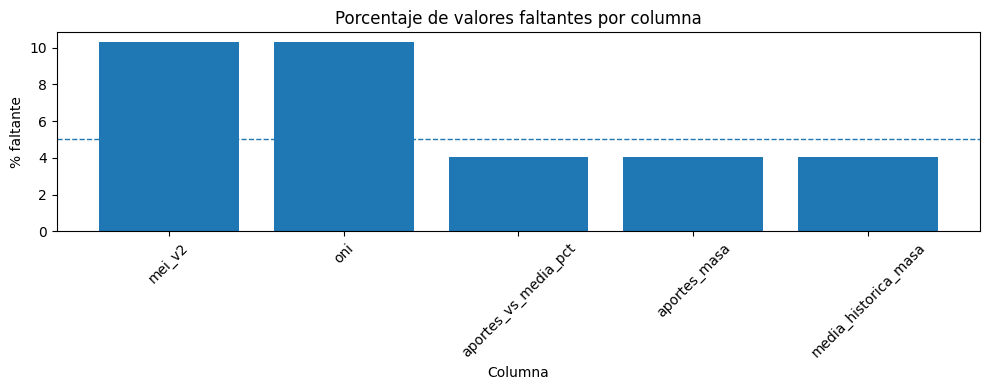

In [22]:
plot_missing_bars(housing)

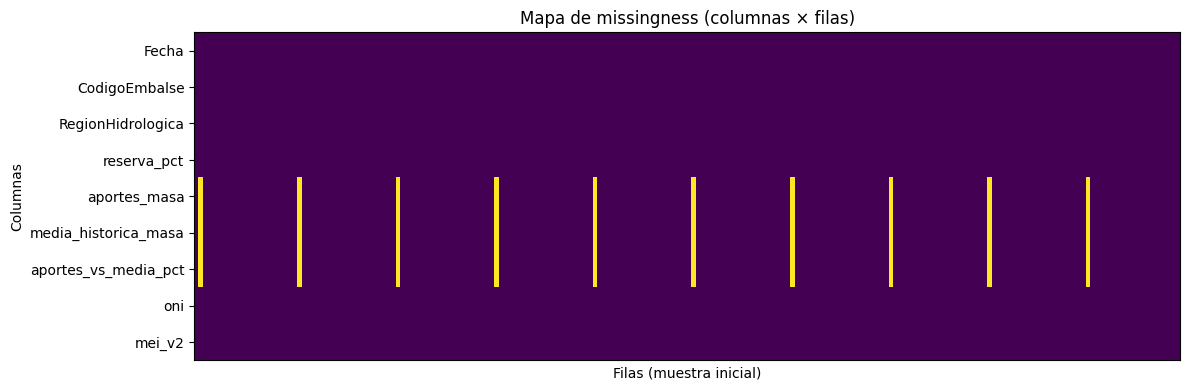

In [23]:
plot_missing_matrix(housing, max_rows=220)

In [25]:
selected_numeric_for_audit = [
    col for col in [
        "mei_v2",
        "oni",
        "aportes_vs_media_pct",
        "aportes_masa",
        "media_historica_masa"
    ]
    if col in housing.columns
]

numeric_profile_df = numeric_profile(housing, selected_numeric_for_audit)

print_section("PERFIL NUMÉRICO ROBUSTO (FEATURES)")
display(numeric_profile_df)


                           PERFIL NUMÉRICO ROBUSTO (FEATURES)                           


,column,mean,median,std,min,q1,q3,max,skew,outlier_pct_iqr
0,mei_v2,-1.930000e-01,-2.300000e-01,9.090000e-01,-2.17,-7.900000e-01,3.400000e-01,2.240000e+00,0.507,1.36
1,oni,9.300000e-02,-1.000000e-01,8.930000e-01,-1.30,-6.000000e-01,5.000000e-01,2.600000e+00,0.866,3.49
2,aportes_vs_media_pct,9.446900e+01,8.392300e+01,5.097500e+01,0.00,6.262300e+01,1.143560e+02,1.878632e+03,4.754,3.91
3,aportes_masa,5.032745e+08,3.132100e+08,5.653772e+08,0.00,1.671270e+08,6.354660e+08,6.356480e+09,2.677,7.99
4,media_historica_masa,5.291777e+08,3.564200e+08,4.764571e+08,0.00,2.230900e+08,8.453200e+08,2.871090e+09,1.546,1.66


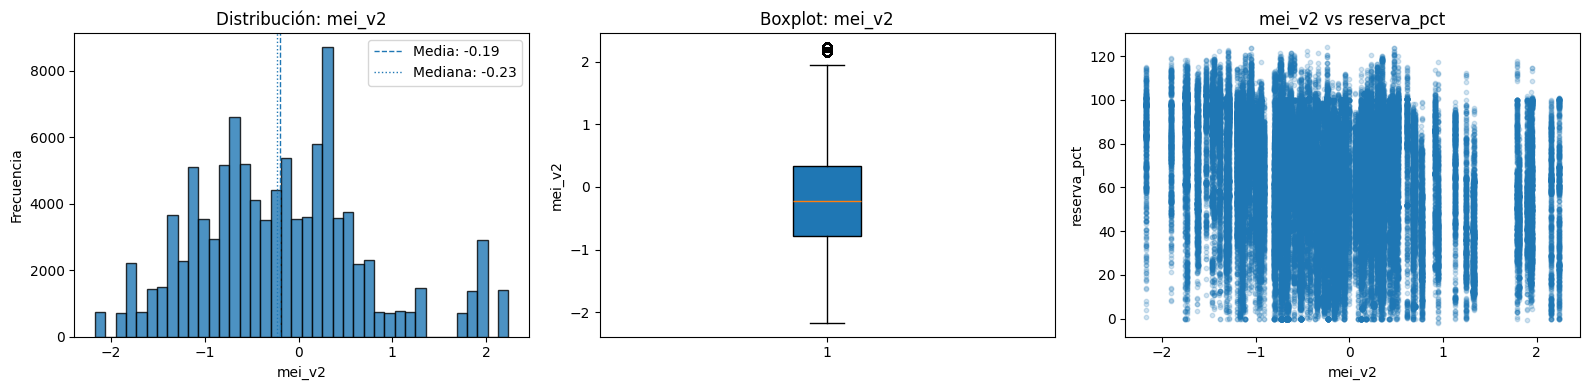

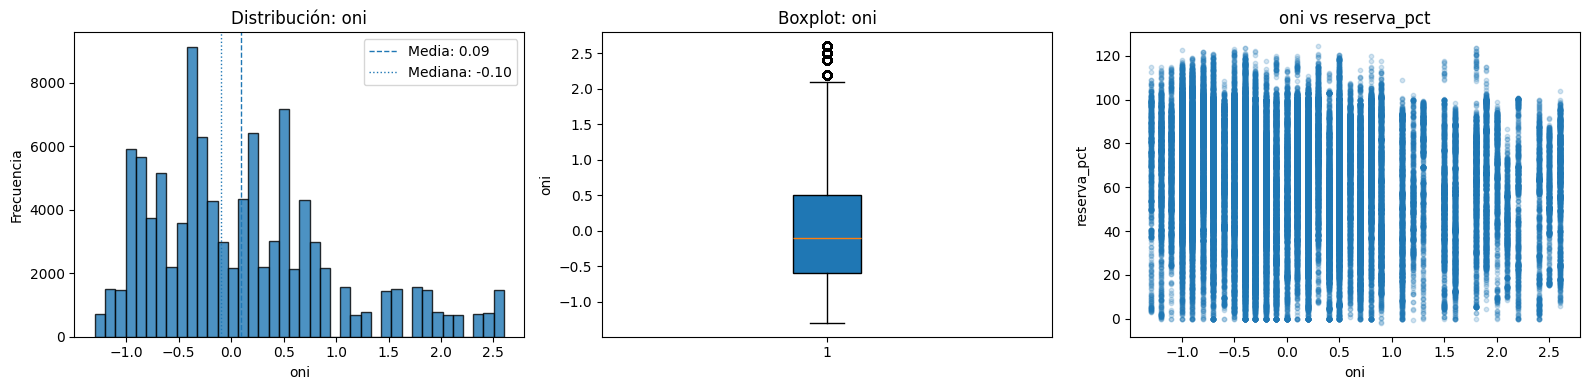

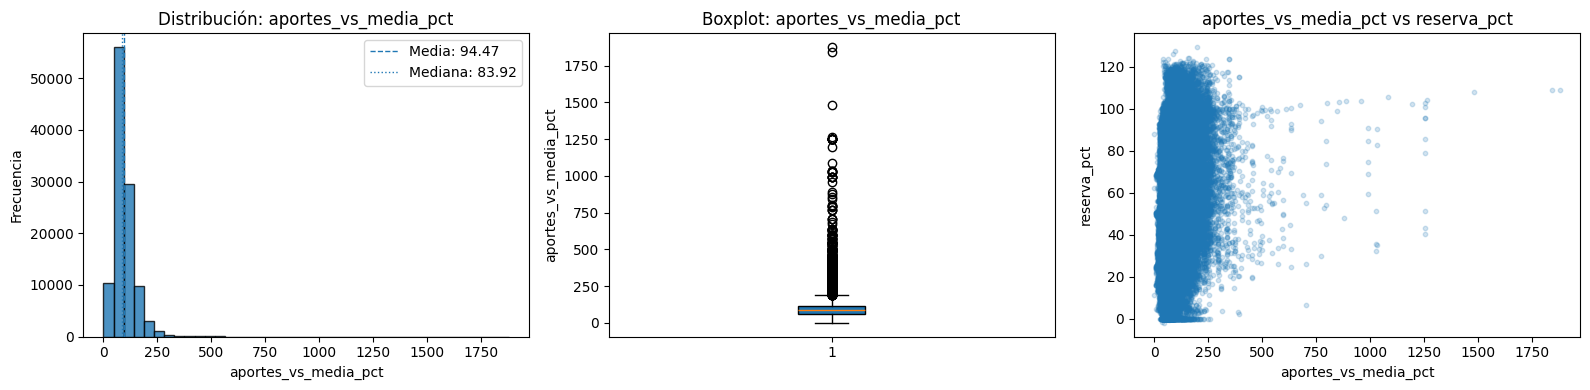

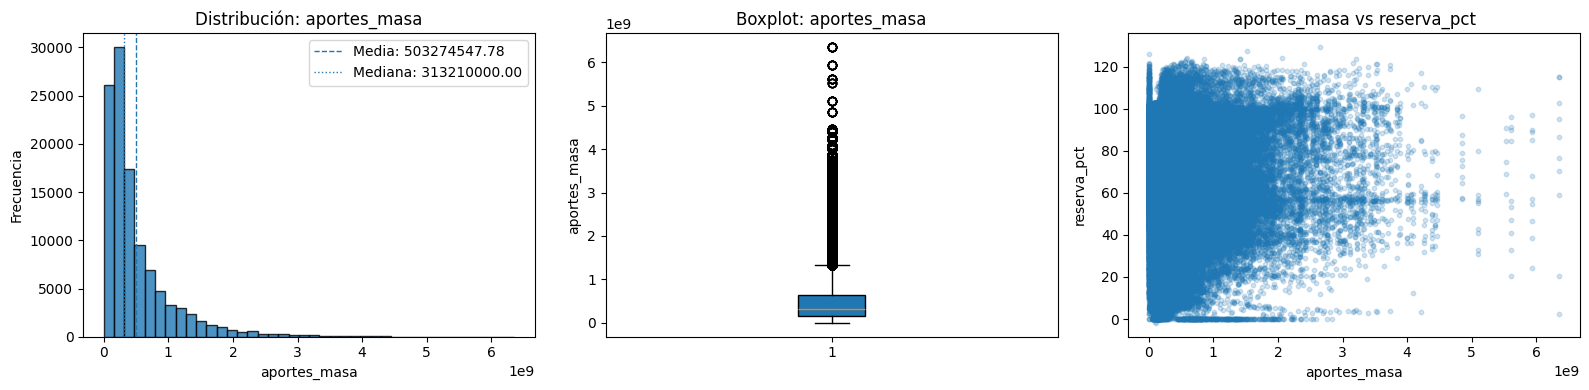

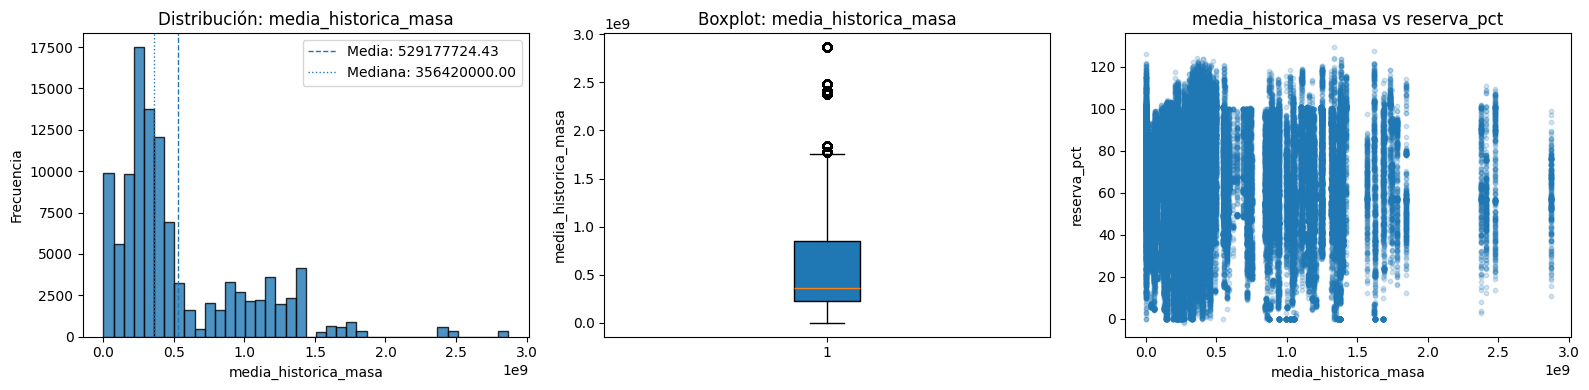

In [26]:
plot_numeric_audit(
    housing,
    columns=[
        col for col in [
            "mei_v2",
            "oni",
            "aportes_vs_media_pct",
            "aportes_masa",
            "media_historica_masa"
        ] if col in housing.columns
    ],
    target="reserva_pct",
)


                              AUDITORÍA CATEGÓRICA: Fecha                               


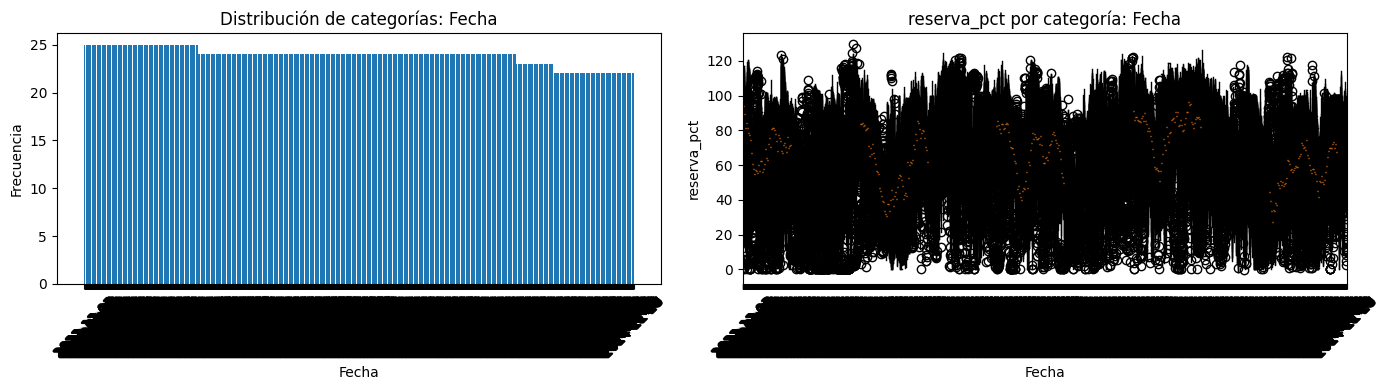


                          AUDITORÍA CATEGÓRICA: CodigoEmbalse                           


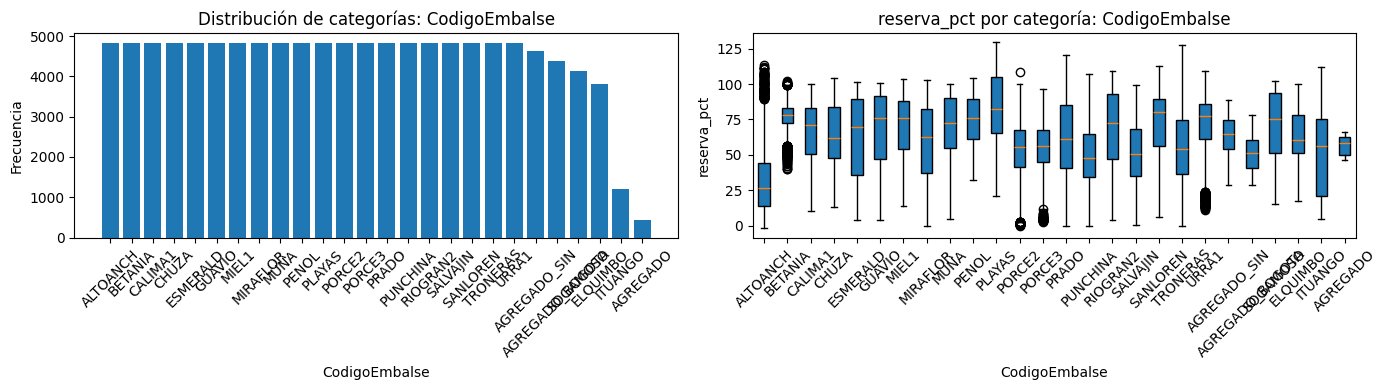


                        AUDITORÍA CATEGÓRICA: RegionHidrologica                         


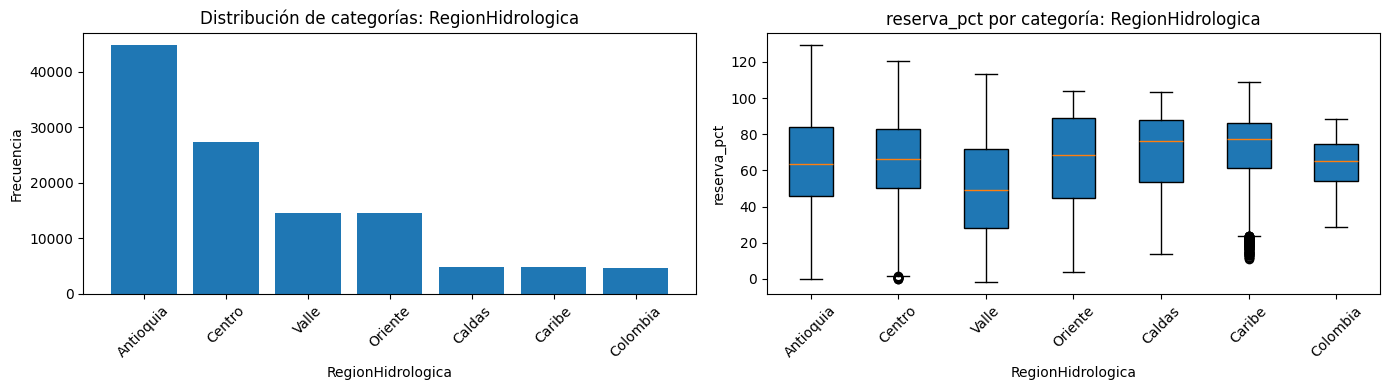

In [27]:
if categorical_cols:
    for cat_col in categorical_cols:
        print_section(f"AUDITORÍA CATEGÓRICA: {cat_col}")
        plot_categorical_audit(housing, cat_col=cat_col, target=TARGET)
else:
    print("⚠️ No hay variables categóricas en el dataset actual.")

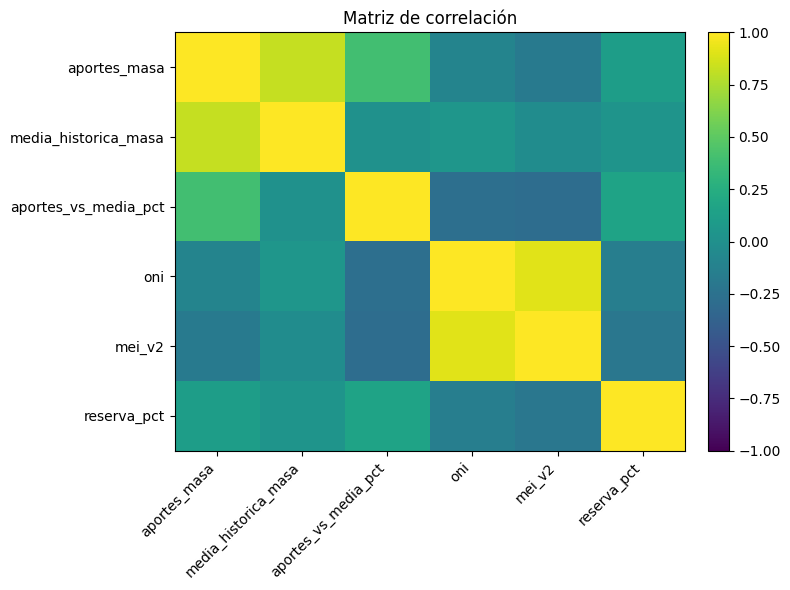

In [28]:
corr_cols = [col for col in numeric_cols + [TARGET] if col in housing.columns]
plot_correlation_heatmap(housing, corr_cols)

In [29]:
target_corr = (
    housing[corr_cols]
    .corr(numeric_only=True)[TARGET]
    .sort_values(ascending=False)
    .drop(TARGET)
    .to_frame(name="corr_with_target")
)

print_section("CORRELACIÓN CON EL TARGET")
display(target_corr)


                               CORRELACIÓN CON EL TARGET                                


,corr_with_target
aportes_vs_media_pct,0.163359
aportes_masa,0.115319
media_historica_masa,0.037044
oni,-0.143194
mei_v2,-0.206126


In [32]:
quick_interpretation(housing, target=TARGET, numeric_cols=numeric_cols)


                                 LECTURA RÁPIDA DEL EDA                                 
- Filas: 115,380
- Columnas: 9
- Target: reserva_pct
- Variables numéricas: 5
- Variables categóricas: 3
- Valores faltantes totales: 37774
- Filas duplicadas exactas: 0
